**What is a Multi-Input Model?**

A multi-input model is a neural network that takes **two or more different types of input** and combines them to make a single prediction. Instead of having one input layer, the network has multiple input branches, each processing a different type of data, which then merge together before making the final prediction.

**Why is it important?**

In the real world, data comes in many forms. For example, when predicting a product's price, you might have:
- **Tabular data**: product size, color, category, brand
- **Text data**: product description, customer reviews
- **Image data**: product photos

Each type of data requires a different processing approach:
- Tabular data → Dense (fully connected) layers
- Text data → RNN, LSTM, or Embedding layers
- Image data → CNN layers

A multi-input model allows you to process each data type with the most appropriate neural network architecture and then combine their learned features to make a final prediction.

**Real-life Use Case: E-commerce Price Prediction**

You're building a model to predict product prices for an e-commerce startup. For each product, you have three types of information:
1. **Product metadata** (tabular): color, size, category, brand
2. **Product description** (text): a detailed description from the website
3. **Product image** (image): photos of the product

By combining information from all three sources, you can make a much more accurate price prediction than using any single source alone.

---


**The Architecture: Multiple Input Branches that Converge**

Think of this architecture as a **funnel**:

```
Tabular Data → Dense Layers ┐
                             ├→ Concatenate → Dense Layers → Output (Price)
Text Data → Embedding → RNN ┘
Image Data → CNN → Flatten  ┘
```
**Step-by-step flow:**

1. **Multiple input layers** – Each input type has its own Input layer with appropriate shape
2. **Branch-specific processing** – Each input goes through layers designed for that data type:
   - Tabular: Dense layers
   - Text: Embedding → RNN/LSTM
   - Image: Conv2D → Pooling → Flatten
3. **Concatenation (merging)** – The outputs from all branches are combined into a single vector
4. **Shared layers** – The concatenated features pass through dense layers to learn interactions between different data types
5. **Output layer** – Final prediction

**Why This Works:**

Different data types contain **complementary information**. For price prediction:
- Metadata gives you the basic product category
- Description text gives you quality indicators and features
- Image gives you visual cues about the product's condition and appearance

By combining all three, the model can make a more informed prediction than any single source could provide.

### 3. Key Points

- Multiple inputs are created by defining **multiple Input layers**
- Each input branch processes its data **independently** using appropriate layers
- Branches are combined using a **merge/concatenate layer**
- After merging, the network continues with **shared dense layers**
- The Functional API allows you to pass multiple inputs as a **list** to the `Model` class
- Different input types require different layer types for optimal performance
- This pattern is called **multi-modal learning** or **data fusion**


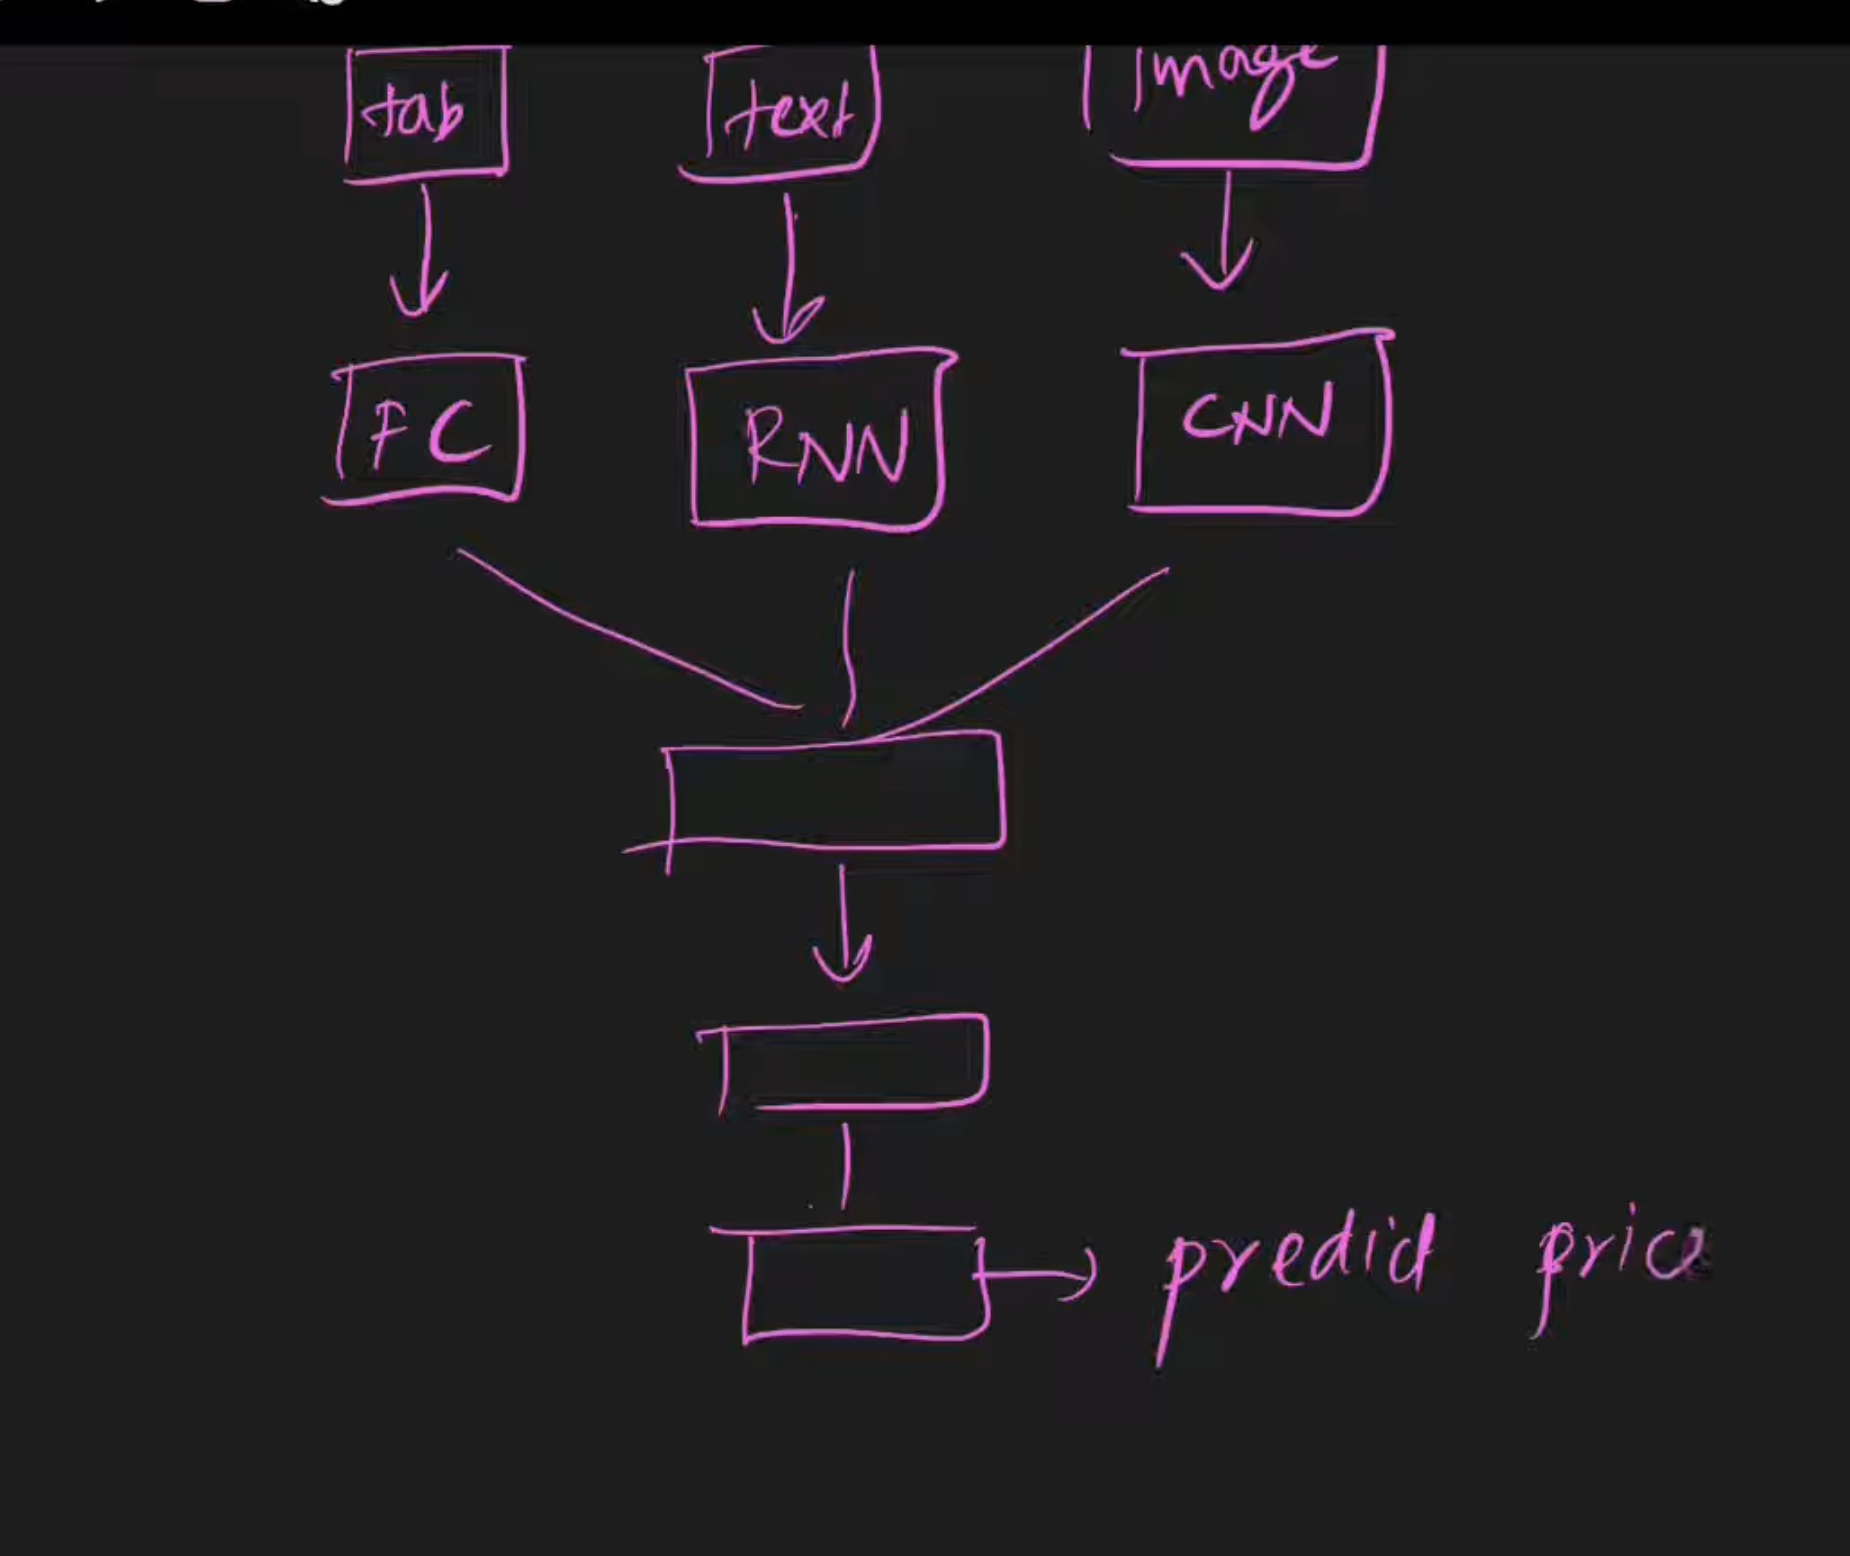

In [10]:
import numpy as np
from keras.models import Model
from keras.layers import Input, Dense, Concatenate, Embedding, LSTM, Flatten
from keras.layers import Conv2D, MaxPooling2D
# (import whatever layers you need)

Step 1: Define multiple input layers

In [3]:
# Input A: Tabular data (e.g., 3 features)
input_a = Input(shape=(3,), name='input_a')

# Input B: Text data (e.g., sequence of 100 words)
input_b = Input(shape=(100,), name='input_b')

# Input C: Image data (e.g., 64x64 RGB image)
input_c = Input(shape=(64, 64, 3), name='input_c')

Step 2: Process each input with appropriate layers

In [ ]:

# Branch A: Tabular → Dense layers
x_a = Dense(32, activation='relu', name='dense_a1')(input_a)
x_a = Dense(16, activation='relu', name='dense_a2')(x_a)

# Branch B: Text → Embedding → LSTM
x_b = Embedding(vocab_size, 50, name='embedding_b')(input_b) # set a value for vocab_size
x_b = LSTM(32, name='lstm_b')(x_b)

# Branch C: Image → CNN → Flatten
x_c = Conv2D(32, (3,3), activation='relu', name='conv_c1')(input_c)
x_c = MaxPooling2D((2,2), name='pool_c1')(x_c)
x_c = Conv2D(64, (3,3), activation='relu', name='conv_c2')(x_c)
x_c = MaxPooling2D((2,2), name='pool_c2')(x_c)
x_c = Flatten(name='flatten_c')(x_c)
x_c = Dense(16, activation='relu', name='dense_c')(x_c)

Step 3: Concatenate all branches

In [ ]:
# Combine all branches
combined = Concatenate(name='concatenate')([x_a, x_b, x_c])

Step 4: Shared layers after concatenation


In [ ]:

z = Dense(32, activation='relu', name='shared1')(combined)
z = Dense(16, activation='relu', name='shared2')(z)
output = Dense(1, activation='linear', name='output')(z)

Step 5: Create the model with multiple inputs

In [ ]:
model = Model(inputs=[input_a, input_b, input_c], outputs=output)

Step 6: Compile and train with multiple inputs



In [ ]:
model.compile(optimizer='adam', loss='mse',metrics=["mae"])

# Training data must be provided as a list matching the input order
model.fit(
    [X_tabular_train, X_text_train, X_image_train],
    y_price_train,
    epochs=10
)


## Complete example

In [12]:
import numpy as np
from keras.models import Model
from keras.layers import Input, Dense, Concatenate, Embedding, LSTM, Flatten
from keras.layers import Conv2D, MaxPooling2D

# --- 1. Generate dummy data ---
n_samples = 1000

# Input A: Tabular data (3 features: size, category, brand)
X_tabular = np.random.rand(n_samples, 3)

# Input B: Text data (sequences of 50 word indices)
X_text = np.random.randint(0, 100, size=(n_samples, 50))  # 100 vocabulary size

# Input C: Image data (32x32 grayscale images, 1 channel)
X_image = np.random.rand(n_samples, 32, 32, 1)

# Output: Price (regression target)
y_price = np.random.rand(n_samples, 1) * 1000  # Prices between 0-1000

# --- 2. Build the model ---

# Input A: Tabular branch
input_tabular = Input(shape=(3,), name='input_tabular')
x_tab = Dense(32, activation='relu', name='tabular_dense1')(input_tabular)
x_tab = Dense(16, activation='relu', name='tabular_dense2')(x_tab)

# Input B: Text branch
input_text = Input(shape=(50,), name='input_text')
x_text = Embedding(100, 20, name='text_embedding')(input_text)  # 100 vocab, 20 embedding dims
x_text = LSTM(32, name='text_lstm')(x_text)  # LSTM returns single vector
x_text = Dense(16, activation='relu', name='text_dense')(x_text)

# Input C: Image branch
input_image = Input(shape=(32, 32, 1), name='input_image')
x_img = Conv2D(32, (3, 3), activation='relu', name='conv1')(input_image)
x_img = MaxPooling2D((2, 2), name='pool1')(x_img)
x_img = Conv2D(64, (3, 3), activation='relu', name='conv2')(x_img)
x_img = MaxPooling2D((2, 2), name='pool2')(x_img)
x_img = Flatten(name='flatten_image')(x_img)
x_img = Dense(16, activation='relu', name='image_dense')(x_img)

# Merge all branches
combined = Concatenate(name='concatenate_layer')([x_tab, x_text, x_img])

# Shared layers after merging
z = Dense(32, activation='relu', name='shared_dense1')(combined)
z = Dense(16, activation='relu', name='shared_dense2')(z)

# Output layer
output = Dense(1, activation='linear', name='price_output')(z)

# Create the model
model = Model(inputs=[input_tabular, input_text, input_image], outputs=output)

# --- 3. Compile the model ---
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- 4. Display model summary ---
model.summary()

# --- 5. Train the model ---
history = model.fit(
    [X_tabular, X_text, X_image],
    y_price,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- 6. Make predictions ---
# New sample: one from each input type
new_tabular = np.random.rand(1, 3)
new_text = np.random.randint(0, 100, size=(1, 50))
new_image = np.random.rand(1, 32, 32, 1)

predicted_price = model.predict([new_tabular, new_text, new_image])
print(f"Predicted price: ${predicted_price[0][0]:.2f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 30, 30,    │        320 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 15, 15,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_text          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 13, 13,    │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tabular       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 50, 20)    │      2,000 │ input_text[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 6, 6, 64)  │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense1      │ (None, 32)        │        128 │ input_tabular[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_lstm (LSTM)    │ (None, 32)        │      6,784 │ text_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_image       │ (None, 2304)      │          0 │ pool2[0][0]       │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense2      │ (None, 16)        │        528 │ tabular_dense1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dense (Dense)  │ (None, 16)        │        528 │ text_lstm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 16)        │     36,880 │ flatten_image[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_layer   │ (None, 48)        │          0 │ tabular_dense2[0… │
│ (Concatenate)       │                   │            │ text_dense[0][0], │
│                     │                   │            │ image_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense1       │ (None, 32)        │      1,568 │ concatenate_laye… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense2       │ (None, 16)        │        528 │ shared_dense1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 67,777 (264.75 KB)

 Trainable params: 67,777 (264.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 321200.1250 - mae: 488.9462 - val_loss: 313925.2812 - val_mae: 478.4556
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 231921.7188 - mae: 398.6967 - val_loss: 97340.5312 - val_mae: 266.6501
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 88465.0078 - mae: 255.5965 - val_loss: 87344.8828 - val_mae: 256.4916
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 82911.3125 - mae: 248.3047 - val_loss: 85057.3984 - val_mae: 253.2315
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 83134.3047 - mae: 248.5296 - val_loss: 85601.8672 - val_mae: 253.5922
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 84906.6016 - mae: 250.8558 - val_loss: 85913.2109 - val_mae: 253.9444
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 82725.5625 - mae: 248.5629 - val_loss: 85006.5000 - val_mae: 253.1351
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 82752.3281 - mae: 249.0990 - val_loss: 85